<a href="https://colab.research.google.com/github/mcrzx/Coverage/blob/main/Predictia_Severitatii_Daunelor_Auto_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicția gravității daunelor în asigurările auto









Predicția severității daunelor auto utilizând Random Forest

Scopul acestui notebook este analiza setului de date Allstate Claims Severity și construirea unui model de Machine Learning pentru estimarea severității daunelor auto. Deoarece variabilele din setul de date sunt anonimizate, analiza se concentrează pe preprocesarea datelor, selecția caracteristicilor și evaluarea performanței modelului predictiv.




### Obiective

1. Cum sunt distribuite valorile despăgubirilor din setul de date?
2. Sunt datele pregătite pentru procesul de modelare?
3. Pot fi eliminate caracteristici redundante fără pierderea informației relevante?
4. Poate algoritmul Random Forest estima severitatea daunelor auto?
5. Care sunt caracteristicile cu cea mai mare influență asupra predicției?

### Prezentarea și analiza setului de date

Analiza a fost realizată utilizând setul de date Allstate Claims Severity, disponibil pe platforma OpenML, care conține informații anonimizate despre despăgubiri din asigurările auto.
https://www.openml.org/search?type=data&sort=runs&id=42571&status=active





##### Importarea bibliotecilor necesare

In [20]:
import pandas as pd
import numpy as np
import pickle
import re
import math
import csv

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import chi2

import seaborn as sns
import matplotlib.pyplot as plt
# %matplotlib inline

# Modificarea opțiunilor de afișare pentru vizualizarea întregului DataFrame
pd.options.display.max_columns = None

##### Colectarea datelor

In [ ]:
# Încărcarea setului de date pentru antrenare
train = pd.read_csv("train.csv")

In [ ]:
# Determinarea dimensiunii setului de date de antrenare
train.shape

(188318, 40)

Setul de date conține 188.318 observații și 132 de coloane.

In [21]:
# Verificarea denumirilor coloanelor
column_names = np.array(train.columns)
print(column_names)

['id' 'cat1' 'cat2' 'cat3' 'cat4' 'cat5' 'cat6' 'cat7' 'cat8' 'cat9'
 'cat10' 'cat11' 'cat12' 'cat13' 'cat14' 'cat15' 'cat16' 'cat17' 'cat18'
 'cat19' 'cat20' 'cat21' 'cat22' 'cat23' 'cat24' 'cat25' 'cat26' 'cat27'
 'cat28' 'cat29' 'cat30' 'cat31' 'cat32' 'cat33' 'cat34' 'cat35' 'cat36'
 'cat37' 'cat38' 'cat39' 'cat40' 'cat41' 'cat42' 'cat43' 'cat44' 'cat45'
 'cat46' 'cat47' 'cat48' 'cat49' 'cat50' 'cat51' 'cat52' 'cat53' 'cat54'
 'cat55' 'cat56' 'cat57' 'cat58' 'cat59' 'cat60' 'cat61' 'cat62' 'cat63'
 'cat64' 'cat65' 'cat66' 'cat67' 'cat68' 'cat69' 'cat70' 'cat71' 'cat72'
 'cat73' 'cat74' 'cat75' 'cat76' 'cat77' 'cat78' 'cat79' 'cat80' 'cat81'
 'cat82' 'cat83' 'cat84' 'cat85' 'cat86' 'cat87' 'cat88' 'cat89' 'cat90'
 'cat91' 'cat92' 'cat93' 'cat94' 'cat95' 'cat96' 'cat97' 'cat98' 'cat99'
 'cat100' 'cat101' 'cat102' 'cat103' 'cat104' 'cat105' 'cat106' 'cat107'
 'cat108' 'cat109' 'cat110' 'cat111' 'cat112' 'cat113' 'cat114' 'cat115'
 'cat116' 'cont1' 'cont2' 'cont3' 'cont4' 'cont5' 'cont

In [ ]:
# Vizualizarea datelor
train.head()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,cat10,cat11,cat12,cat13,cat14,cat15,cat16,cat17,cat18,cat19,cat20,cat21,cat22,cat23,cat24,cat25,cat26,cat27,cat28,cat29,cat30,cat31,cat32,cat33,cat34,cat35,cat36,cat37,cat38,cat39,cat40,cat41,cat42,cat43,cat44,cat45,cat46,cat47,cat48,cat49,cat50,cat51,cat52,cat53,cat54,cat55,cat56,cat57,cat58,cat59,cat60,cat61,cat62,cat63,cat64,cat65,cat66,cat67,cat68,cat69,cat70,cat71,cat72,cat73,cat74,cat75,cat76,cat77,cat78,cat79,cat80,cat81,cat82,cat83,cat84,cat85,cat86,cat87,cat88,cat89,cat90,cat91,cat92,cat93,cat94,cat95,cat96,cat97,cat98,cat99,cat100,cat101,cat102,cat103,cat104,cat105,cat106,cat107,cat108,cat109,cat110,cat111,cat112,cat113,cat114,cat115,cat116,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1,A,B,A,B,A,A,A,A,B,A,B,A,A,A,A,A,A,A,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,D,B,B,D,D,B,D,C,B,D,B,A,A,A,A,A,D,B,C,E,A,C,T,B,G,A,A,I,E,G,J,G,BU,BC,C,AS,S,A,O,LB,0.726300,0.245921,0.187583,0.789639,0.310061,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,D,B,B,D,D,A,B,C,B,D,B,A,A,A,A,A,D,D,C,E,E,D,T,L,F,A,A,E,E,I,K,K,BI,CQ,A,AV,BM,A,O,DP,0.330514,0.737068,0.592681,0.614134,0.885834,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,B,B,B,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,D,B,B,B,D,B,D,C,B,B,B,A,A,A,A,A,D,D,C,E,E,A,D,L,O,A,B,E,F,H,F,A,AB,DK,A,C,AF,A,I,GK,0.261841,0.358319,0.484196,0.236924,0.397069,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,A,A,D,B,B,D,D,D,B,C,B,D,B,A,A,A,A,A,D,D,C,E,E,D,T,I,D,A,A,E,E,I,K,K,BI,CS,C,N,AE,A,O,DJ,0.321594,0.555782,0.527991,0.373816,0.422268,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,B,A,B,A,A,A,A,A,A,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,A,A,A,D,B,D,B,D,B,B,C,B,B,C,A,A,A,B,H,D,B,D,E,E,A,P,F,J,A,A,D,E,K,G,B,H,C,C,Y,BM,A,K,CK,0.273204,0.159990,0.527991,0.473202,0.704268,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


- __id__ reprezintă coloana de identificare unică a observațiilor
- __cat1__ - __cat116__ sunt variabile categoriale
- __cont1__ - __cont14__ sunt variabile continue
- __loss__ loss reprezintă variabila dependentă (variabila țintă)

# RQ1. Cum sunt distribuite valorile despăgubirilor?

In [5]:
# Analiza statistică a variabilei țintă (loss)
train['loss'].describe()

,loss
count,188318.000000
mean,3037.337686
std,2904.086186
min,0.670000
25%,1204.460000
50%,2115.570000
75%,3864.045000
max,121012.250000


In [7]:
# Cea mai mare despăgubire din dataset
train['loss'].max()

121012.25

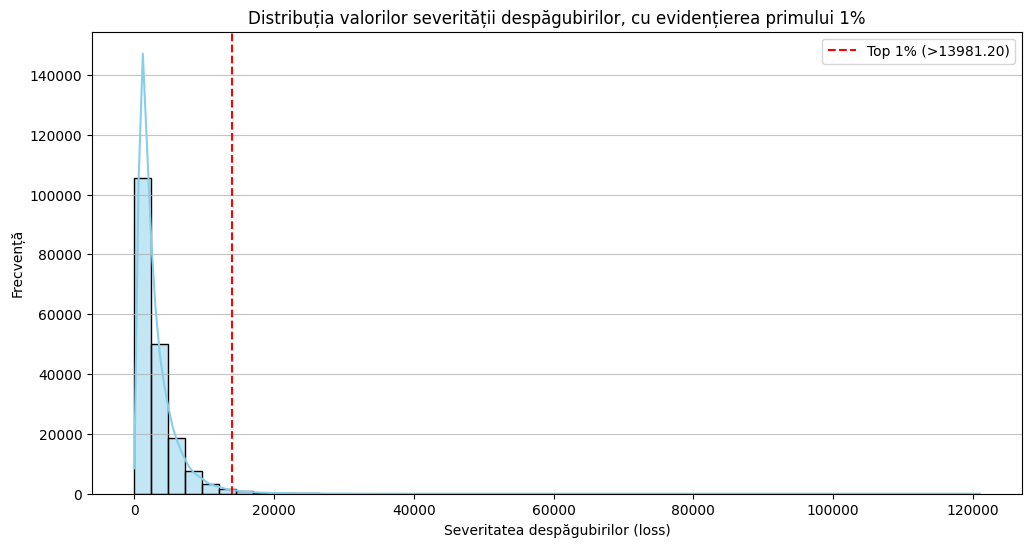

In [11]:
#Analiza distribuției variabilei țintă (loss)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asigurăm că variabila „loss” este în scala sa originală pentru această vizualizare
# Dacă a fost transformată logaritmic, se aplică np.exp()
# Presupunem că „train” conține în prezent valorile transformate logaritmic ale variabilei „loss”
# Creăm o serie temporară pentru reprezentare grafică, pentru a evita modificarea
# DataFrame-ului „train” necesară în pașii următori
# DataFrame-ul „train” a fost reîncărcat într-o celulă anterioară, astfel încât
# train['loss'] este deja în scala sa originală.
# Aplicarea funcției np.exp() asupra valorilor originale produce depășiri de capacitate („overflow”)
# și valori infinite („inf”).
original_loss_values = train['loss']

# Calcularea percentilei 99 a valorilor variabilei „loss”
ninety_ninth_percentile = original_loss_values.quantile(0.99)

# Crearea histogramei
plt.figure(figsize=(12, 6))
sns.histplot(original_loss_values, bins=50, kde=True, color='skyblue')

# Adăugarea unei linii verticale care marchează percentila 99
plt.axvline(ninety_ninth_percentile, color='red', linestyle='--', label=f'Top 1% (>{ninety_ninth_percentile:.2f})')

plt.title('Distribuția valorilor severității despăgubirilor, cu evidențierea primului 1%')
plt.xlabel('Severitatea despăgubirilor (loss)')
plt.ylabel('Frecvență')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# Sortarea setului de date descrescător după variabila „loss” și afișarea primelor 5 valori
# (păstrând funcționalitatea cerută inițial)
# Side note: dacă train['loss'] este necesară în scala logaritmică pentru alte etape,
# această celulă nu trebuie să modifice permanent valorile.
# Dacă dorim afișarea primelor 5 despăgubiri în scala originală pornind de la datele transformate,
# este necesară reconversia valorilor.
# Pentru moment, păstrăm train.sort_values(), care operează asupra valorilor existente.
# Dacă intenția este afișarea primelor 5 despăgubiri în scala originală:
# top_5_claims_original_scale = pd.DataFrame({'loss_original_scale': original_loss_values}).sort_values(by='loss_original_scale', ascending=False).head(5)
# display(top_5_claims_original_scale)


Pentru a înțelege distribuția severității daunelor, a fost analizată variabila țintă loss. Histograma permite observarea modului în care sunt distribuite valorile despăgubirilor și evidențiază cele mai severe 1% dintre cazuri.

# RQ2. Cum pot fi rafinate datele pentru construirea unui model predictiv eficient?

In [4]:
# Determinarea numărului de observații, a tipurilor de variabile și a variabilei țintă
import pandas as pd

# Tipul de date al fiecărui atribut
train = pd.read_csv("train.csv")
num_observations = train.shape[0]

# Reidentificarea coloanelor categoriale și continue din cadrul DataFrame-ului curent
current_column_datatypes = train.dtypes
current_categorical_columns = list(current_column_datatypes[current_column_datatypes == "object"].index.values)
current_continuous_columns = list(current_column_datatypes[current_column_datatypes == "float64"].index.values)

# Coloana „loss” reprezintă variabila țintă și poate fi inclusă în lista variabilelor continue,
# însă aceasta nu este o caracteristică de intrare (feature).
# Vom utiliza în mod explicit „loss/pierdere” ca nume al variabilei țintă.
target_variable_name = 'pierdere'

# Dacă „loss” se află încă în lista variabilelor continue,
# o eliminăm pentru a calcula corect numărul caracteristicilor continue
if target_variable_name in current_continuous_columns:
    current_continuous_columns.remove(target_variable_name)

num_categorical_vars = len(current_categorical_columns)
num_continuous_vars = len(current_continuous_columns)

summary_data = {
    'Indicator': [
        'Numărul de observații',
        'Numărul de variabile categoriale',
        'Numărul de variabile continue',
        'Variabila țintă'
    ],
    'Valoare': [
        num_observations,
        num_categorical_vars,
        num_continuous_vars,
        target_variable_name
    ]
}

summary_df = pd.DataFrame(summary_data)
print("Rezumatul setului de date:")
display(summary_df)


Rezumatul setului de date:


,Indicator,Valoare
0,Numărul de observații,188318
1,Numărul de variabile categoriale,116
2,Numărul de variabile continue,15
3,Variabila țintă,pierdere


Setul de date conține 116 variabile categoriale și 14 variabile continue, ceea ce justifică necesitatea unor etape de preprocesare și selecție a caracteristicilor.

In [13]:
# Verificarea calității datelor
train.isnull().sum()

,0
id,0
cat1,0
cat2,0
cat3,0
cat4,0
...,...
cont11,0
cont12,0
cont13,0
cont14,0


Nicio coloană nu conține valori lipsă.




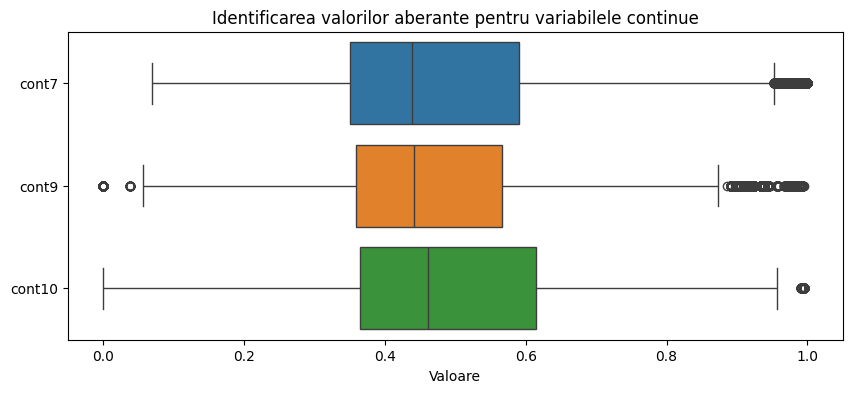

In [2]:
# Identificarea valorilor aberante (outlieri) pentru variabilele continue selectate
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

train = pd.read_csv("train.csv")

outlier_cols = ['cont7', 'cont9', 'cont10']

plt.figure(figsize=(10, 4))

sns.boxplot(data=train[outlier_cols], orient='h')

plt.title('Identificarea valorilor aberante pentru variabilele continue')
plt.xlabel('Valoare')
plt.show()

Boxplot-ul arată că variabilele cont7, cont9 și cont10 conțin câteva valori neobișnuit de mari sau de mici comparativ cu restul observațiilor. Aceste valori sunt numite outlieri și pot influența rezultatele modelului de Machine Learning.

# RQ3. Pot fi eliminate caracteristici redundante fără pierderea informației relevante?

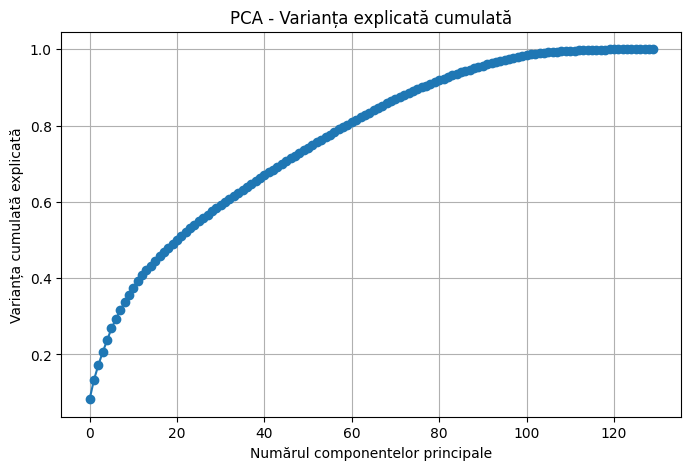

In [6]:
# Aplicarea analizei PCA pentru evaluarea posibilității de reducere a dimensionalității setului de date
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer  # Corrected import for SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Load the training data (re-load to ensure fresh start) ---
train = pd.read_csv("train.csv")

# --- Step 2: Re-identify categorical and continuous columns ---
# This is crucial as the 'train' DataFrame might have been reset or modified
column_datatypes = train.dtypes
categorical_columns = list(column_datatypes[column_datatypes == "object"].index.values)
continuous_columns = list(column_datatypes[column_datatypes == "float64"].index.values)

# Remove 'id' and 'loss' from continuous_columns if they are present, as they are not features for PCA yet
if 'id' in continuous_columns:
    continuous_columns.remove('id')
if 'loss' in continuous_columns:
    continuous_columns.remove('loss')

# --- Step 3: Handle missing values (re-apply for robustness) ---
# For continuous columns, impute with median
for col in continuous_columns:
    if train[col].isnull().any():
        median_imputer = SimpleImputer(strategy='median')
        train[col] = median_imputer.fit_transform(train[[col]])

# For categorical columns, impute with most frequent
for col in categorical_columns:
    if train[col].isnull().any():
        most_frequent_imputer = SimpleImputer(strategy='most_frequent')
        train[col] = most_frequent_imputer.fit_transform(train[[col]])

# --- Step 4: Handle outliers for specific continuous columns (re-apply) ---
outlier_cols = ['cont7', 'cont9', 'cont10']
for col in outlier_cols:
    if col in train.columns:
        Q1 = train[col].quantile(0.25)
        Q3 = train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        median_value = train[col].median()
        train.loc[(train[col] < lower_bound) | (train[col] > upper_bound), col] = median_value

# --- Step 5: Label Encode categorical variables (re-apply) ---
for col in categorical_columns:
    if col in train.columns and train[col].dtype == 'object':
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col])

# --- Step 6: Drop correlated features (using globally defined lists) ---
# 'correlated_features' and 'columns_to_drop_cat' should be available from previous cells
# Ensure these variables are properly populated before this cell runs or define them here if context is lost.
# For safety, let's re-define them if they might not be globally available in isolated run.
# However, assuming they are available from the notebook's execution history.

# Combine and filter columns to drop to ensure they exist in the current DataFrame
all_cols_to_drop = []
if 'correlated_features' in globals():
    all_cols_to_drop.extend(list(correlated_features))
if 'columns_to_drop_cat' in globals():
    all_cols_to_drop.extend(list(columns_to_drop_cat))

columns_to_actually_drop = [col for col in all_cols_to_drop if col in train.columns]
train = train.drop(columns=columns_to_actually_drop, axis=1)

# --- Step 7: Log transform 'loss' (if it exists and is not dropped) ---
# This is typically done for the target variable, but for PCA on features, 'loss' is excluded from X.
# However, if other parts of the notebook rely on 'loss' being log-transformed, it's good to keep it consistent.
if 'loss' in train.columns:
    train['loss'] = np.log(train['loss'])

# --- Step 8: Select numerical features for PCA (excluding 'id' and 'loss') ---
# X will now contain all numerical features after preprocessing
X = train.drop(columns=['loss', 'id'], errors='ignore')

# --- Step 9: Standardize features ---
X_scaled = StandardScaler().fit_transform(X)

# --- Step 10: Perform PCA ---
pca = PCA(n_components=None)
pca.fit(X_scaled)

# Varianța cumulată explicată (Cumulative Explained Variance)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# --- Step 11: Plot cumulative explained variance ---
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Numărul componentelor principale')
plt.ylabel('Varianța cumulată explicată')
plt.title('PCA - Varianța explicată cumulată')
plt.grid(True)
plt.show()

Analiza PCA indică faptul că informația din setul de date este distribuită între un număr mare de caracteristici. Pentru păstrarea a aproximativ 80% din varianța totală sunt necesare în jur de 60 de componente principale, ceea ce sugerează că o reducere moderată a dimensionalității este posibilă fără pierderi majore de informație.

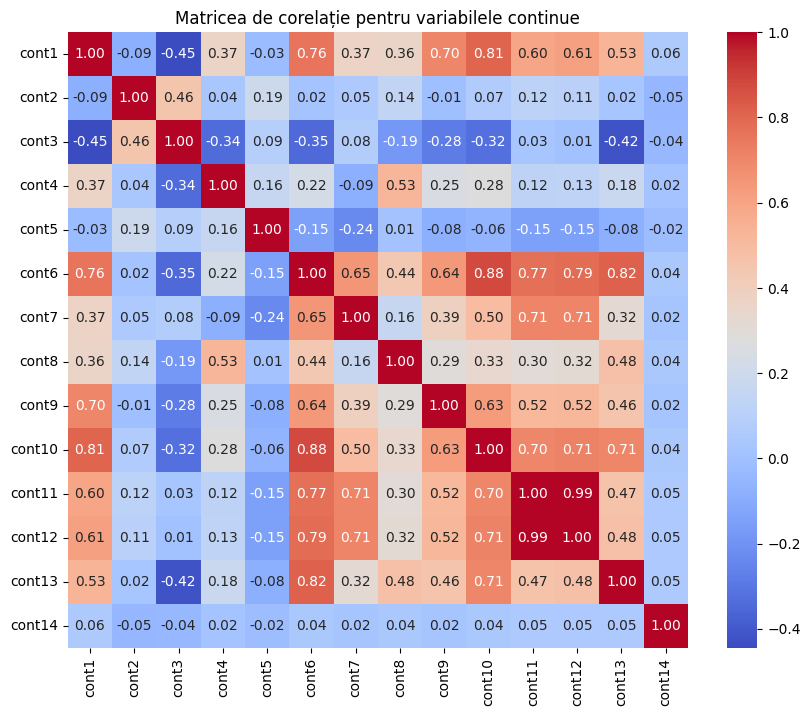

In [7]:
# Construirea matricei de corelație pentru variabilele continue
import matplotlib.pyplot as plt
import seaborn as sns

# Corelația dintre variabilele continue
corr_matrix = train[continuous_columns].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            annot=True,
            fmt='.2f')

plt.title('Matricea de corelație pentru variabilele continue')
plt.show()

Matricea de corelație evidențiază existența unor relații puternice între anumite variabile continue. Cea mai ridicată corelație este observată între variabilele cont11 și cont12 (0,99), ceea ce sugerează că acestea furnizează informații foarte similare. De asemenea, se observă corelații ridicate între cont6 și cont10 (0,88), respectiv cont6 și cont13 (0,82).

,Caracteristica,Scor_Chi2
100,cat101,157078.634447
110,cat111,19241.392485
11,cat12,19123.637795
78,cat79,14724.403768
9,cat10,14716.144207
79,cat80,14152.507571
102,cat103,12482.136755
0,cat1,10050.241974
56,cat57,9729.986527
10,cat11,9577.110282


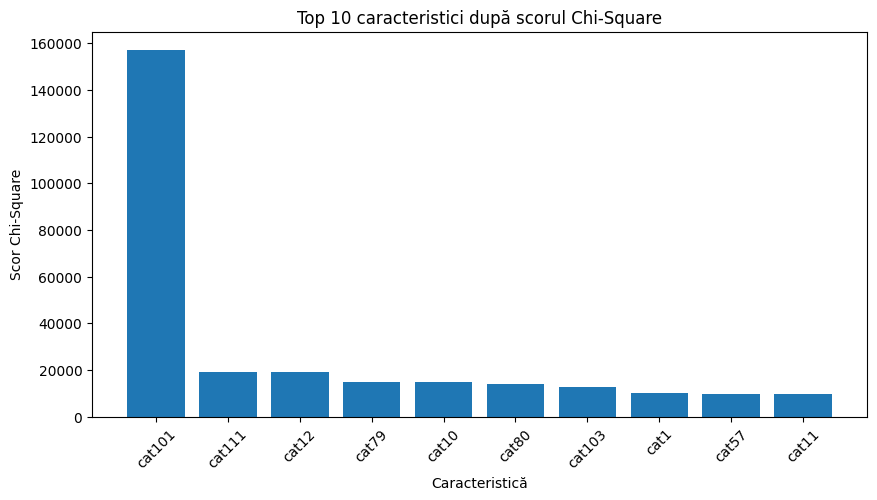

In [8]:
# Evaluarea importanței variabilelor categoriale utilizând testul Chi-Square
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd
import matplotlib.pyplot as plt

# Variabile categorice codificate
X_cat = train[[col for col in train.columns if col.startswith('cat')]]

# Variabila țintă
y = pd.qcut(train['loss'], q=5, labels=False)

# Chi-Square
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_cat, y)

chi_scores = pd.DataFrame({
    'Caracteristica': X_cat.columns,
    'Scor_Chi2': chi_selector.scores_
})

chi_scores = chi_scores.sort_values(
    by='Scor_Chi2',
    ascending=False
)

display(chi_scores.head(10))

# Grafic Top 10
plt.figure(figsize=(10,5))
plt.bar(
    chi_scores['Caracteristica'].head(10),
    chi_scores['Scor_Chi2'].head(10)
)

plt.title('Top 10 caracteristici după scorul Chi-Square')
plt.xlabel('Caracteristică')
plt.ylabel('Scor Chi-Square')
plt.xticks(rotation=45)
plt.show()

Testul Chi-Square a evidențiat faptul că anumite caracteristici categoriale au o influență mai mare asupra variabilei țintă decât altele. Variabila cat101 a înregistrat cel mai ridicat scor Chi-Square, urmată de cat111, cat12 și cat79, ceea ce sugerează că acestea conțin informații relevante pentru estimarea severității daunelor.

# RQ4. Poate algoritmul Random Forest estima severitatea daunelor auto?

In [9]:
# Separarea datelor pentru antrenarea și evaluarea modelului Random Forest
from sklearn.model_selection import train_test_split

X = train.drop(['loss', 'id'], axis=1)
y = train['loss']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(150654, 130)
(37664, 130)


Setul de date a fost împărțit în două subseturi: 150.654 observații pentru antrenarea modelului și 37.664 observații pentru testare. Astfel, 80% din date au fost utilizate pentru construirea modelului, iar 20% pentru evaluarea performanței acestuia pe observații noi.

In [12]:
# Configurarea modelului Random Forest pentru estimarea severității daunelor
RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

A fost configurat un model Random Forest Regressor cu 50 de arbori de decizie. Parametrul random_state=42 asigură reproducibilitatea rezultatelor, iar n_jobs=-1 utilizează toate nucleele disponibile pentru accelerarea procesării.

In [13]:
# Antrenarea modelului Random Forest pe datele de antrenare
rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

Modelul a fost antrenat utilizând setul de date de antrenare. În această etapă, algoritmul învață relațiile dintre caracteristicile disponibile și severitatea daunelor auto, reprezentată prin variabila țintă loss.

In [14]:
# Estimarea severității daunelor utilizând modelul antrenat
y_pred = rf.predict(X_test)

print(y_pred[:10])

[7.62843018 7.24369632 8.00675121 7.71313607 7.05754492 8.35180901
 7.76327736 7.47209858 7.41035158 7.13821738]


După antrenare, modelul Random Forest a fost utilizat pentru estimarea valorilor variabilei țintă pentru observațiile din setul de testare. Valorile afișate reprezintă primele predicții generate de model.

In [15]:
# Evaluarea performanței modelului utilizând metrici specifice regresiei
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 0.4365518552140177
RMSE = 0.5614642516610182
R² = 0.5173625815621223


Performanța modelului a fost evaluată utilizând metricile MAE, RMSE și R². Valoarea R² de aproximativ 0,52 indică faptul că modelul explică circa 52% din variația severității daunelor. Valorile MAE și RMSE sugerează că modelul realizează predicții cu un nivel moderat de eroare.

*   MAE = 0.44 → eroare medie relativ redusă.
*   RMSE = 0.56 → erorile mari sunt moderate.
*   R² = 0.52 → modelul explică aproximativ 52% din variabilitatea despăgubirilor.

# RQ5. Care sunt caracteristicile cele mai importante pentru predicție?

In [16]:
# Identificarea caracteristicilor cu cea mai mare contribuție la predicție
importance = pd.DataFrame({
    'Caracteristica': X_train.columns,
    'Importanta': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importanta',
    ascending=False
)

importance.head(10)

,Caracteristica,Importanta
79,cat80,0.230778
129,cont14,0.053844
100,cat101,0.051882
122,cont7,0.036773
117,cont2,0.033368
102,cat103,0.028605
78,cat79,0.027819
110,cat111,0.024128
99,cat100,0.023794
111,cat112,0.020880


Tabelul prezintă primele 10 caracteristici identificate de modelul Random Forest ca fiind cele mai relevante pentru estimarea severității daunelor. Dintre acestea, cat80 are cea mai mare contribuție la procesul de predicție, urmată de cont14, cat101 și cont7.

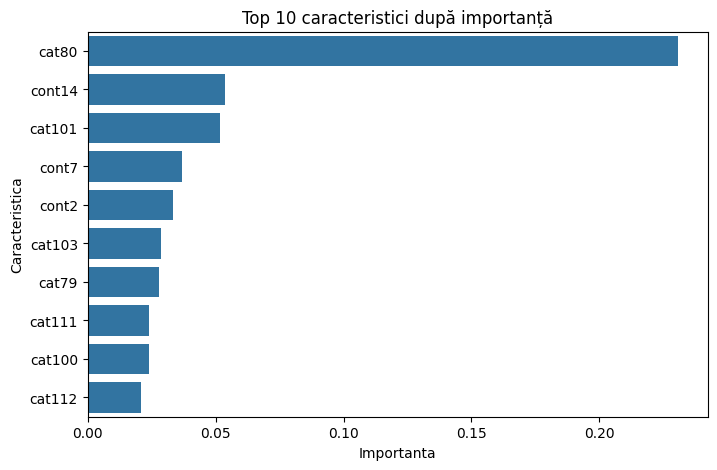

In [17]:
# Reprezentarea grafică a celor mai importante 10 caracteristici identificate de model
top10 = importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    data=top10,
    x='Importanta',
    y='Caracteristica'
)

plt.title('Top 10 caracteristici după importanță')
plt.show()

Figura prezintă cele mai importante 10 caracteristici identificate de modelul Random Forest. Se observă că variabila cat80 are cea mai mare influență asupra predicției severității daunelor, având un scor de importanță semnificativ mai ridicat decât celelalte caracteristici. Restul variabilelor contribuie într-o măsură mai redusă, însă rămân relevante pentru performanța modelului.